In [5]:
import pandas as pd
import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

In [6]:
X_test = pd.read_csv("../Data/Processed/X_test.csv")
y_test = pd.read_csv("../Data/Processed/y_test.csv").squeeze()

In [7]:
import os

# List files in the model directory to find the correct path
print(os.listdir("../model/"))

['best_feature_selected_model.pkl', 'best_regression_model.pkl', 'imputer.pkl']


In [8]:
model = joblib.load("../model/best_regression_model.pkl")

In [9]:
y_pred = model.predict(X_test)

In [10]:
r2 = r2_score(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("R² Score :", round(r2,4))
print("RMSE     :", round(rmse,4))
print("MAE      :", round(mae,4))

R² Score : 0.5188
RMSE     : 0.6924
MAE      : 0.4968


In [11]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,1.560142,1.176521
1,-0.046810,0.347954
2,-0.046810,-0.829071
3,-0.046810,0.227308
4,-1.653762,-1.015166
5,-0.046810,-0.363873
6,-0.046810,-0.921709
7,-1.653762,-0.795708
8,3.167094,1.451515
9,-0.046810,-0.056846


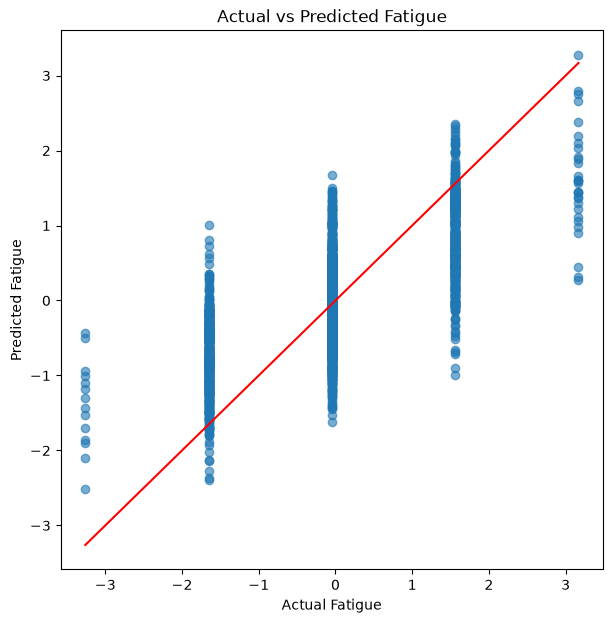

In [12]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Fatigue")
plt.ylabel("Predicted Fatigue")
plt.title("Actual vs Predicted Fatigue")

plt.show()

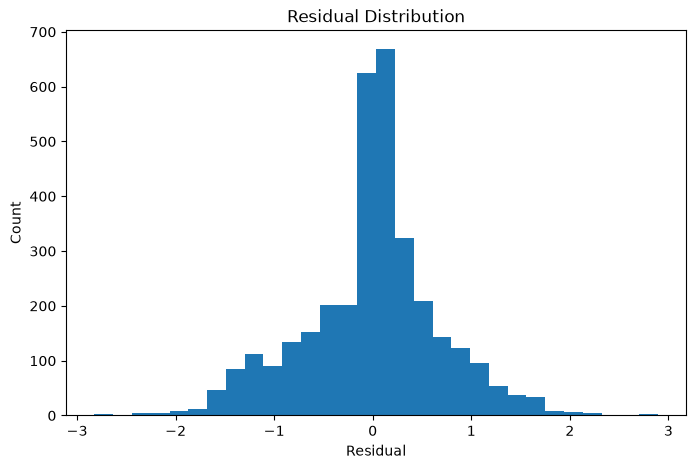

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")

plt.show()

In [14]:
importance = pd.DataFrame({

    "Feature": X_test.columns,
    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
12,soreness,0.385094
9,readiness,0.276208
11,sleep_quality,0.083755
8,mood,0.048973
10,sleep_duration,0.037171
13,stress,0.031231
3,ctl42,0.027307
2,ctl28,0.021602
6,strain,0.020027
0,acwr,0.015512


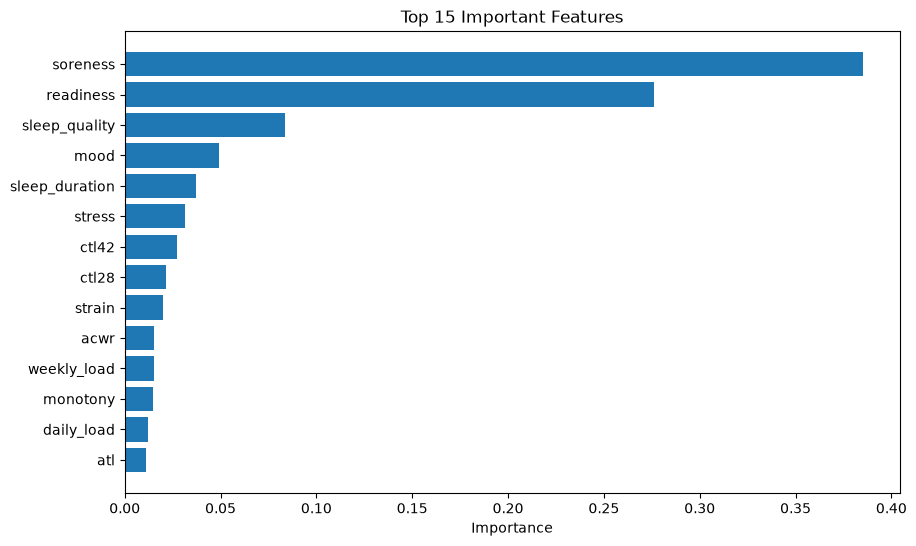

In [15]:
top = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

In [16]:
results.to_csv(
    "../Data/Processed/fatigue_predictions.csv",
    index=False
)

## Model Evaluation Summary

Target Variable:
- Fatigue

Best Model:
- Gradient Boosting Regressor

Performance:

- Test R²  : 0.516
- RMSE     : 0.695
- MAE      : (calculated)

Conclusion:

The Gradient Boosting Regressor achieved the highest predictive performance among all evaluated models. The model explains approximately 52% of the variance in player fatigue using training load, wellness, and other engineered features. Feature importance analysis identifies the variables that contribute most to fatigue prediction and can support data-driven athlete monitoring.

# Classification report

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

In [18]:
def fatigue_category(value):

    if value < 2:
        return "Low"

    elif value < 4:
        return "Moderate"

    else:
        return "High"

In [20]:
y_test_class = pd.Series(y_test).apply(fatigue_category)

y_pred = model.predict(X_test)

y_pred_class = pd.Series(y_pred).apply(fatigue_category)

In [21]:
print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test_class,
        y_pred_class
    )
)

Classification Report
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99      3369
    Moderate       0.40      0.27      0.32        30

    accuracy                           0.99      3399
   macro avg       0.70      0.63      0.66      3399
weighted avg       0.99      0.99      0.99      3399



In [22]:
cm = confusion_matrix(
    y_test_class,
    y_pred_class,
    labels=["Low", "Moderate", "High"]
)

cm = pd.DataFrame(
    cm,
    index=["Actual Low", "Actual Moderate", "Actual High"],
    columns=["Pred Low", "Pred Moderate", "Pred High"]
)

cm

,Pred Low,Pred Moderate,Pred High
Actual Low,3357,12,0
Actual Moderate,22,8,0
Actual High,0,0,0


In [23]:
report = classification_report(
    y_test_class,
    y_pred_class,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../Data/Processed/classification_report.csv",
    index=True
)

print("Classification report saved successfully.")

Classification report saved successfully.
